In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
import xgboost as xgb
import mlflow
from mlflow.models import infer_signature


setting the url for metrics tracking

In [51]:
mlflow.set_tracking_uri("http://127.0.0.1:8080")

In [52]:
print(mlflow.get_tracking_uri())


http://127.0.0.1:8080


In [296]:
df=pd.read_csv('/Users/ashish/Desktop/House-Price-Prediction/final_housing.csv')

In [297]:
df

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,renovated
0,0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,0
1,1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1
2,2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,0
3,3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,0
4,4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,98103,47.6993,-122.346,0
21609,21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,98146,47.5107,-122.362,0
21610,21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,98144,47.5944,-122.299,0
21611,21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,98027,47.5345,-122.069,0


In [298]:
df=df.drop(columns=['Unnamed: 0'])

Performing one hot encoding for the pincode feature

In [299]:
df_encoded = pd.get_dummies(df, columns=['zipcode'],dtype=int)

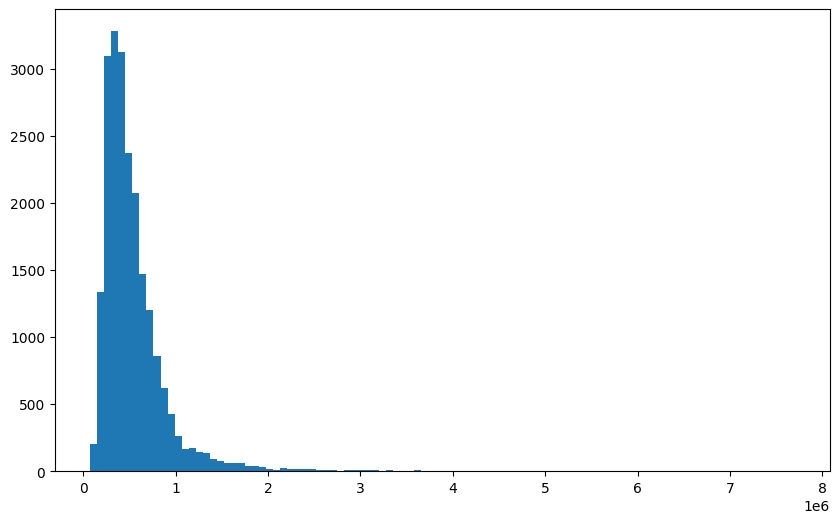

In [300]:
#the figure shows that the price(target variable is right skewed) with outliers----performing log transformation to contain the value within a smaller range of values
plt.figure(figsize=(10,6))
plt.hist(df_encoded['price'],bins=100)
plt.show()

In [301]:
df_encoded['price']=np.log(df_encoded['price'])

In [302]:
df_encoded.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,12.309982,3,1.00,1180,5650,1.0,0,0,3,7,...,0,0,0,0,0,0,1,0,0,0
1,13.195614,3,2.25,2570,7242,2.0,0,0,3,7,...,0,0,0,0,0,0,0,0,0,0
2,12.100712,2,1.00,770,10000,1.0,0,0,3,6,...,0,0,0,0,0,0,0,0,0,0
3,13.311329,4,3.00,1960,5000,1.0,0,0,5,7,...,0,0,0,0,0,0,0,0,0,0
4,13.142166,3,2.00,1680,8080,1.0,0,0,3,8,...,0,0,0,0,0,0,0,0,0,0


In [303]:
X=df_encoded.iloc[:,1:].to_numpy()
y=df_encoded.iloc[:,0].to_numpy()

In [304]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [33]:
X_train

array([[3.00e+00, 1.75e+00, 1.78e+03, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       [2.00e+00, 1.00e+00, 1.00e+03, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       [3.00e+00, 1.00e+00, 1.08e+03, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       ...,
       [3.00e+00, 2.50e+00, 2.12e+03, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       [1.00e+00, 7.50e-01, 3.80e+02, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       [4.00e+00, 2.50e+00, 3.13e+03, ..., 0.00e+00, 0.00e+00, 0.00e+00]],
      shape=(17290, 85))

Linear regression model

In [139]:
params={"fit_intercept":True}

In [140]:
reg=LinearRegression(**params)

In [141]:
reg.fit(X_train,y_train)

LinearRegression()

In [142]:
reg.coef_

array([ 2.11038498e-03,  4.23124024e-02,  1.25899104e-04,  6.62474763e-07,
       -3.81672818e-02,  4.41033430e-01,  6.86411644e-02,  5.40954610e-02,
        1.04321391e-01,  1.07099116e-04,  1.87999879e-05, -5.72048824e-04,
        5.76073221e-01, -3.60583341e-01,  6.57813175e-02, -3.38842333e-01,
       -3.62120863e-01, -3.60667823e-01,  6.12947004e-01,  2.64729075e-01,
        2.07183540e-01,  1.79536951e-01,  1.76190156e-01, -6.56209049e-03,
       -1.07247499e-01, -9.26462857e-02, -1.22116900e-01, -1.57075820e-01,
       -4.09049277e-01,  7.33901752e-02,  1.39609060e-01, -1.64021293e-01,
        2.10436831e-01, -2.94348549e-01, -2.89117270e-01, -4.28315902e-01,
        2.48539969e-01, -1.79928253e-02, -1.05154811e-01,  7.38555289e-01,
        4.00968148e-01, -2.60631600e-01,  7.78113955e-02,  1.50761993e-01,
        1.33609521e-01, -2.68740893e-01, -1.14252984e-01, -2.18415662e-01,
       -5.66876587e-02,  1.00196870e-01, -1.85558313e-01, -3.80428865e-02,
        1.25354077e-01,  

In [143]:
reg.intercept_

np.float64(-58.80200744441453)

In [144]:
y_pred=reg.predict(X_test)

In [160]:
print(reg.score(X_test,y_test))
print(r2_score(y_test,y_pred))
r2score=r2_score(y_test,y_pred)

0.8721230036723651
0.8721229647073059


In [151]:
mse=mean_squared_error(y_test,y_pred)

In [152]:
rmse=root_mean_squared_error(y_test,y_pred)

In [153]:
#performing cross-validation to get the generalized accuracy of the model
cv_model=cross_val_score(reg,X,y,cv=5,scoring='r2')
print(cv_model)
print(cv_model.mean())

[0.87297765 0.8677143  0.86604766 0.87764175 0.8731279 ]
0.871501852561057


In [57]:

mlflow.set_experiment("Regression")


2025/04/15 02:37:40 INFO mlflow.tracking.fluent: Experiment with name 'Regression' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/571892435618044896', creation_time=1744664860287, experiment_id='571892435618044896', last_update_time=1744664860287, lifecycle_stage='active', name='Regression', tags={}>

In [58]:

with mlflow.start_run():
    # Log parameters
    mlflow.log_params(params)

    # Log metrics
    mlflow.log_metric("R2_score", r2score)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)

    # Set tags
    mlflow.set_tag("Training Info", "Basic Linear regression for housing dataset")

    # Log model
    signature = infer_signature(X_train, reg.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        sk_model=reg,
        artifact_path="Housing_model",
        signature=signature,
        input_example=X_train,
        registered_model_name="Linear regression",
    )


Successfully registered model 'Linear regression'.
2025/04/15 02:37:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Linear regression, version 1


🏃 View run casual-moose-243 at: http://127.0.0.1:8080/#/experiments/571892435618044896/runs/8a437106a040453c97d9752bb5768f69
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/571892435618044896


Created version '1' of model 'Linear regression'.


In [52]:
###using ridge regression to introduce penalty to the variables

In [161]:
params={"alpha":0.01}

In [162]:
ridge=Ridge(**params)

In [172]:
ridge.fit(X_train,y_train)

Ridge(alpha=0.01)

In [173]:
y_pred=ridge.predict(X_test)

In [174]:
mse=mean_squared_error(y_test,y_pred)

In [175]:
rmse=root_mean_squared_error(y_test,y_pred)

In [179]:
print(r2_score(y_test,y_pred))
print(ridge.score(X_test,y_test))
r2score=r2_score(y_test,y_pred)

0.8721229647073059
0.8721229647073059


In [180]:
print(mse)
print(rmse)
print(r2score)

0.036449051915670404
0.19091634795289378
0.8721229647073059


In [181]:

with mlflow.start_run():
    # Log parameters
    mlflow.log_params(params)

    # Log metrics
    mlflow.log_metric("R2_score", r2score)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)

    # Set tags
    mlflow.set_tag("Training Info", "Ridge regression for housing dataset")

    # Log model
    signature = infer_signature(X_train, reg.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        sk_model=ridge,
        artifact_path="Housing_model",
        signature=signature,
        input_example=X_train,
        registered_model_name="Ridge regression",
    )


Successfully registered model 'Ridge regression'.
2025/04/15 02:58:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Ridge regression, version 1


🏃 View run dapper-cod-670 at: http://127.0.0.1:8080/#/experiments/571892435618044896/runs/039684cfae1848579854e826aa136eca
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/571892435618044896


Created version '1' of model 'Ridge regression'.


#using grid search to find the best value for random_forst such as n_estimators, max_depth

In [193]:
grid ={"max_depth":list(np.arange(10,14)),"n_estimators":[100,200,400]}

In [194]:
ran_for=RandomForestRegressor()

In [195]:
knn_cv=GridSearchCV(ran_for,grid,cv=5)

In [196]:
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [np.int64(10), np.int64(11), np.int64(12),
                                       np.int64(13)],
                         'n_estimators': [100, 200, 400]})

In [197]:
print("tuned hyperparameter K:",knn_cv.best_params_)
print("tuned parameters: (best score):",knn_cv.best_score_) 
print(knn_cv.best_estimator_)          #cross validation score using k-fold technique

tuned hyperparameter K: {'max_depth': np.int64(13), 'n_estimators': 400}
tuned parameters: (best score): 0.8849207049354921
RandomForestRegressor(max_depth=np.int64(13), n_estimators=400)


In [198]:
params={"max_depth":13,"n_estimators":400}

In [199]:
final_randomforest=RandomForestRegressor(**params)

In [200]:
final_randomforest.fit(X_train,y_train)

RandomForestRegressor(max_depth=13, n_estimators=400)

In [202]:
y_pred=final_randomforest.predict(X_test)

In [203]:
r2score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
print(r2score,mse,rmse)

0.8878153413703977 0.03197622182257259 0.178818963822556


In [204]:

with mlflow.start_run():
    # Log parameters
    mlflow.log_params(params)

    # Log metrics
    mlflow.log_metric("R2_score", r2score)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)

    # Set tags
    mlflow.set_tag("Training Info", "Random forst regressor for housing dataset")

    # Log model
    signature = infer_signature(X_train, final_randomforest.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        sk_model=final_randomforest,
        artifact_path="Housing_model",
        signature=signature,
        input_example=X_train,
        registered_model_name="Random Forest Regressor",
    )


Successfully registered model 'Random Forest Regressor'.
2025/04/15 04:11:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Random Forest Regressor, version 1


🏃 View run unleashed-zebra-608 at: http://127.0.0.1:8080/#/experiments/571892435618044896/runs/9ba270e2b544409d88e6cf11e9b7545d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/571892435618044896


Created version '1' of model 'Random Forest Regressor'.


In [272]:
param_grid={
    "max_depth":[8,10,13,15,20],
    "learning_rate":[0.1,0.05,0.01],
    "n_estimators":[200,300,400,500],
    "reg_alpha":[0, 0.1, 0.5],
    'reg_lambda': [1.0, 2.0]
    
}



In [206]:

xgb_model=xgb.XGBRegressor()

In [273]:
grid_search=GridSearchCV(xgb_model,param_grid=param_grid,cv=5,scoring='neg_mean_squared_error')


In [274]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.05, 0.01],
                         'max_depth': [8, 10, 13, 15, 20],
                         'n_estimators': [200, 300, 400, 500],
                         'reg_alpha': [0, 0.1, 0.5], 'reg_lambda': [1.0, 2.0]},
             scoring='neg_mean_squared_error')

In [275]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 1.0}
-0.027376698643389208


In [305]:
params={
    "learning_rate":0.05,
    "max_depth":8,
    "n_estimators":300,
    "reg_lambda":1.0,
    "reg_alpha":0.5,
    "random_state":42,
}

In [306]:
xgb_regressor=xgb.XGBRegressor(**params)

In [307]:
xgb_regressor.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [308]:
y_pred=xgb_regressor.predict(X_test)

In [309]:
r2score=r2_score(y_test,y_pred)
print(r2score)

0.9045854898976557


In [310]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

0.027196192219098907


In [311]:
rmse=root_mean_squared_error(y_test,y_pred)
print(rmse)

0.16491268058914968


In [283]:
with mlflow.start_run():
    # Log parameters
    mlflow.log_params(params)

    # Log metrics
    mlflow.log_metric("R2_score", r2score)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)

    # Set tags for easier search/filtering
    mlflow.set_tag("Training Info", "XGB regressor for housing dataset")
    mlflow.set_tag("developer", "your_name")

    # Log model with signature and input example
    signature = infer_signature(X_train, xgb_regressor.predict(X_train))
    model_info = mlflow.xgboost.log_model(
        xgb_model=xgb_regressor,
        artifact_path="Housing_model",
        signature=signature,
        input_example=X_train,
        registered_model_name="XG Regressor"
    )


/Users/ashish/anaconda3/envs/house_prediction/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [07:13:45] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
Successfully registered model 'XG Regressor'.
2025/04/15 07:13:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XG Regressor, version 1


🏃 View run burly-yak-139 at: http://127.0.0.1:8080/#/experiments/571892435618044896/runs/83fdccc7b04e413f90f77d130d9aa47e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/571892435618044896


Created version '1' of model 'XG Regressor'.


In [284]:
#now we'll check whether one hot encoding is really required to train the tree-based model

In [285]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,98103,47.6993,-122.346,0
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,98146,47.5107,-122.362,0
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,98144,47.5944,-122.299,0
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,98027,47.5345,-122.069,0


In [286]:
df['price']=np.log(df['price'])

In [287]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [289]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [290]:
params={
    "learning_rate":0.05,
    "max_depth":8,
    "n_estimators":300,
    "random_state":42,
}

In [291]:
xgr=xgb.XGBRegressor(**params)

In [292]:
xgr.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#the metric shows that there's a limited effect of one-hot encoding on the xg-boost algorithm
xgr.score(X_test,y_test)

0.9042425460737